# Import

In [ ]:
#pip install numpy==1.26.4

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


from PIL import Image
import os
from os import listdir
import time
import functools

from sklearn import manifold, decomposition
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, auc, roc_auc_score, roc_curve
from glob import glob


import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50V2, NASNetMobile
from tensorflow.keras.applications import vgg16, resnet_v2, nasnet
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalAveragePooling1D, Flatten, Dense, Dropout
from tensorflow.keras.layers import Rescaling, RandomFlip, RandomRotation, RandomZoom, Input, RandomTranslation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical

In [2]:
import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
#pip install plot_keras_history

In [4]:
from sklearn import preprocessing
import cv2
from sklearn import cluster, metrics
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from matplotlib.image import imread

In [5]:
cv2.__version__

'4.11.0'

In [6]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [7]:
def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

file_name = 'flipkart_updated_1.csv'
local_path = 'data/'
colab_path = '/content/drive/MyDrive/Colab Notebooks/p6/data/'

def get_path(local=local_path, colab=colab_path):
  if is_colab():
      from google.colab import drive
      drive.mount('/content/drive')
      file_path = colab
  else:
      # Chemin local
      file_path = local

  return file_path

file_path = get_path() + file_name
print(file_path)

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/p6/data/flipkart_updated_1.csv


In [8]:
# load csv

#df = pd.read_csv('data/flipkart_updated_1.csv')
df = pd.read_csv(file_path)

df.shape

(1050, 9)

# Vérification données

In [9]:
df.head(3)

,uniq_id,product_name,product_category_tree,image,description,brand,cat_1,cat_2,cat_3
0,55b85ea15a1536d46b7190ad6fff8ce7,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",55b85ea15a1536d46b7190ad6fff8ce7.jpg,Key Features of Elegance Polyester Multicolor ...,Elegance,Home Furnishing,Curtains & Accessories,Curtains
1,7b72c92c2f6c40268628ec5f14c6d590,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",7b72c92c2f6c40268628ec5f14c6d590.jpg,Specifications of Sathiyas Cotton Bath Towel (...,Sathiyas,Baby Care,Baby Bath & Skin,Baby Bath Towels
2,64d5d4a258243731dc7bbb1eef49ad74,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",64d5d4a258243731dc7bbb1eef49ad74.jpg,Key Features of Eurospa Cotton Terry Face Towe...,Eurospa,Baby Care,Baby Bath & Skin,Baby Bath Towels


In [10]:
#df['image'] = df['image'].apply(lambda x: "data/Images/" + str(x))
#df.head(3)

images_path = 'Images/'

path = get_path() + images_path
print(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/p6/data/Images/


In [11]:
def show_cat_img(df, path, cat, img_qt):
    grouped = df.groupby(cat).head(img_qt)

    for category, group in grouped.groupby(cat):
        print(f"Catégorie: {category}")
        plt.figure(figsize=(4, 2))
        for idx, (i, row) in enumerate(group.iterrows()):
            image_path = path + row['image']
            if os.path.exists(image_path):
                img = Image.open(image_path)
                plt.subplot(1, img_qt, idx + 1)  # Utiliser idx + 1 pour s'assurer que l'index est correct
                plt.imshow(img)
                plt.axis('off')
            else:
                print(f"Image non trouvée: {image_path}")
        plt.show()

Catégorie: Baby Care


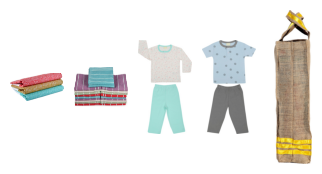

Catégorie: Beauty and Personal Care


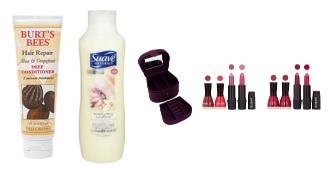

Catégorie: Computers


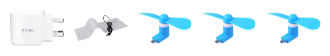

Catégorie: Home Decor & Festive Needs


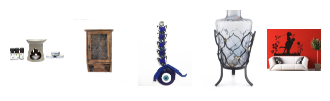

Catégorie: Home Furnishing


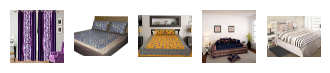

Catégorie: Kitchen & Dining


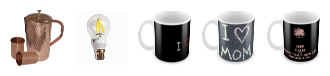

Catégorie: Watches


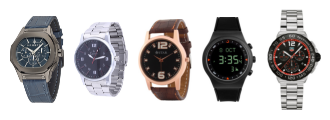

In [12]:
show_cat_img(df, path, 'cat_1', 5)

# Modèle SIFT

In [ ]:
df_label = df[['image', 'description','cat_1']].copy()

le = preprocessing.LabelEncoder()
df_label["label"] = le.fit_transform(df_label["cat_1"])

df_label

,image,description,cat_1,label
0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,Key Features of Elegance Polyester Multicolor ...,Home Furnishing,4
1,7b72c92c2f6c40268628ec5f14c6d590.jpg,Specifications of Sathiyas Cotton Bath Towel (...,Baby Care,0
2,64d5d4a258243731dc7bbb1eef49ad74.jpg,Key Features of Eurospa Cotton Terry Face Towe...,Baby Care,0
3,d4684dcdc759dd9cdf41504698d737d8.jpg,Key Features of SANTOSH ROYAL FASHION Cotton P...,Home Furnishing,4
4,6325b6870c54cd47be6ebfbffa620ec7.jpg,Key Features of Jaipur Print Cotton Floral Kin...,Home Furnishing,4
...,...,...,...,...
1045,958f54f4c46b53c8a0a9b8167d9140bc.jpg,Oren Empower Extra Large Self Adhesive Sticker...,Baby Care,0
1046,fd6cbcc22efb6b761bd564c28928483c.jpg,Wallmantra Large Vinyl Sticker Sticker (Pack o...,Baby Care,0
1047,5912e037d12774bb73a2048f35a00009.jpg,Buy Uberlyfe Extra Large Pigmented Polyvinyl F...,Baby Care,0
1048,c3edc504d1b4f0ba6224fa53a43a7ad6.jpg,Buy Wallmantra Medium Vinyl Sticker Sticker fo...,Baby Care,0


In [ ]:
df_label['cat_1'].unique()

array(['Home Furnishing', 'Baby Care', 'Watches',
       'Home Decor & Festive Needs', 'Kitchen & Dining',
       'Beauty and Personal Care', 'Computers'], dtype=object)

In [ ]:
df_label

,image,description,cat_1,label
0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,Key Features of Elegance Polyester Multicolor ...,Home Furnishing,4
1,7b72c92c2f6c40268628ec5f14c6d590.jpg,Specifications of Sathiyas Cotton Bath Towel (...,Baby Care,0
2,64d5d4a258243731dc7bbb1eef49ad74.jpg,Key Features of Eurospa Cotton Terry Face Towe...,Baby Care,0
3,d4684dcdc759dd9cdf41504698d737d8.jpg,Key Features of SANTOSH ROYAL FASHION Cotton P...,Home Furnishing,4
4,6325b6870c54cd47be6ebfbffa620ec7.jpg,Key Features of Jaipur Print Cotton Floral Kin...,Home Furnishing,4
...,...,...,...,...
1045,958f54f4c46b53c8a0a9b8167d9140bc.jpg,Oren Empower Extra Large Self Adhesive Sticker...,Baby Care,0
1046,fd6cbcc22efb6b761bd564c28928483c.jpg,Wallmantra Large Vinyl Sticker Sticker (Pack o...,Baby Care,0
1047,5912e037d12774bb73a2048f35a00009.jpg,Buy Uberlyfe Extra Large Pigmented Polyvinyl F...,Baby Care,0
1048,c3edc504d1b4f0ba6224fa53a43a7ad6.jpg,Buy Wallmantra Medium Vinyl Sticker Sticker fo...,Baby Care,0


In [ ]:
df_label['label'].unique()

array([4, 0, 6, 3, 5, 1, 2])

## Pre-processing images : réduction de taille de fichiers

In [ ]:
print(images_path)

Images/


In [ ]:
#path = 'data/Images/'

new_path = 'data/Images_process/'
new_images_path = 'Images_process/'

path = get_path() + images_path
new_path = get_path() + new_images_path
print(path)
print(new_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/p6/data/Images/
/content/drive/MyDrive/Colab Notebooks/p6/data/Images_process/


In [ ]:
def preprocess_image(image, max_size=255):
    # Redimensionner l'image tout en conservant le ratio d'aspect
    height, width = image.shape
    if height > width:
        if height > max_size:
            scale = max_size / height
            new_width = int(width * scale)
            image = cv2.resize(image, (new_width, max_size))
    else:
        if width > max_size:
            scale = max_size / width
            new_height = int(height * scale)
            image = cv2.resize(image, (max_size, new_height))

    return image

In [ ]:
def preprocess_folder(path, max_size):
    # Créer le répertoire de sortie s'il n'existe pas
    os.makedirs(new_path, exist_ok=True)

    # Appliquer le prétraitement et sauvegarder les images
    for index, row in df_label.iterrows():
        image_path = os.path.join(path, row['image'])
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if image is not None:
            preprocessed_image = preprocess_image(image)

            # Sauvegarder l'image prétraitée
            new_image_path = os.path.join(new_path, row['image'])
            cv2.imwrite(new_image_path, (preprocessed_image * max_size).astype(np.uint8))
            print(f"Image sauvegardée: {new_image_path}")
        else:
            print(f"Image non trouvée: {image_path}")

In [ ]:
def preprocess_folder(path, new_path, max_size, force_save=False):
    # Créer le répertoire de sortie s'il n'existe pas
    os.makedirs(new_path, exist_ok=True)

    # Compter le nombre d'éléments dans les dossiers
    num_elements_path = len(os.listdir(path))
    num_elements_new_path = len(os.listdir(new_path))

    # Vérifier si le nombre d'éléments est le même et si force_save est False
    if num_elements_path == num_elements_new_path and not force_save:
        print("Le nombre d'éléments dans les deux dossiers est le même. Aucun prétraitement nécessaire.")
        return

    # Appliquer le prétraitement et sauvegarder les images
    for index, row in df_label.iterrows():
        image_path = os.path.join(path, row['image'])
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if image is not None:
            preprocessed_image = preprocess_image(image, max_size)

            # Sauvegarder l'image prétraitée
            new_image_path = os.path.join(new_path, row['image'])
            cv2.imwrite(new_image_path, preprocessed_image)
            print(f"Image sauvegardée: {new_image_path}")
        else:
            print(f"Image non trouvée: {image_path}")

In [ ]:
preprocess_folder(path, new_path, max_size=255)

Le nombre d'éléments dans les deux dossiers est le même. Aucun prétraitement nécessaire.


In [ ]:
def get_directory_size(directory):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(directory):
        for filename in filenames:
            file_path = os.path.join(dirpath, filename)
            # Ajouter la taille du fichier à la taille totale
            total_size += os.path.getsize(file_path)
    return total_size

# Obtenir la taille totale des répertoires
original_size_bytes = get_directory_size(path)
processed_size_bytes = get_directory_size(new_path)

# Convertir en kilo-octets (KB) et méga-octets (MB)
original_size_kb = original_size_bytes / 1024
processed_size_kb = processed_size_bytes / 1024

original_size_mb = original_size_kb / 1024
processed_size_mb = processed_size_kb / 1024

# Afficher les tailles
print(f"Taille totale du répertoire original: {original_size_kb:.2f} KB ({original_size_mb:.2f} MB)")
print(f"Taille totale du répertoire traité: {processed_size_kb:.2f} KB ({processed_size_mb:.2f} MB)")

# Comparaison
size_difference_kb = original_size_kb - processed_size_kb
size_difference_mb = size_difference_kb / 1024
print(f"Différence de taille: {size_difference_kb:.2f} KB ({size_difference_mb:.2f} MB)")

Taille totale du répertoire original: 357305.14 KB (348.93 MB)
Taille totale du répertoire traité: 17519.48 KB (17.11 MB)
Différence de taille: 339785.66 KB (331.82 MB)


In [ ]:
def get_file_sizes(directory):
    file_sizes = []
    for filename in os.listdir(directory):
        file_path = os.path.join(directory, filename)
        if os.path.isfile(file_path):
            # Taille en octets
            size_bytes = os.path.getsize(file_path)

            # Lire l'image pour obtenir les dimensions en pixels
            image = cv2.imread(file_path)
            if image is not None:
                height, width = image.shape[:2]
                size_pixels = width * height
            else:
                size_pixels = None

            file_sizes.append({
                'filename': filename,
                'size_bytes': size_bytes,
                'size_pixels': size_pixels
            })
    return file_sizes

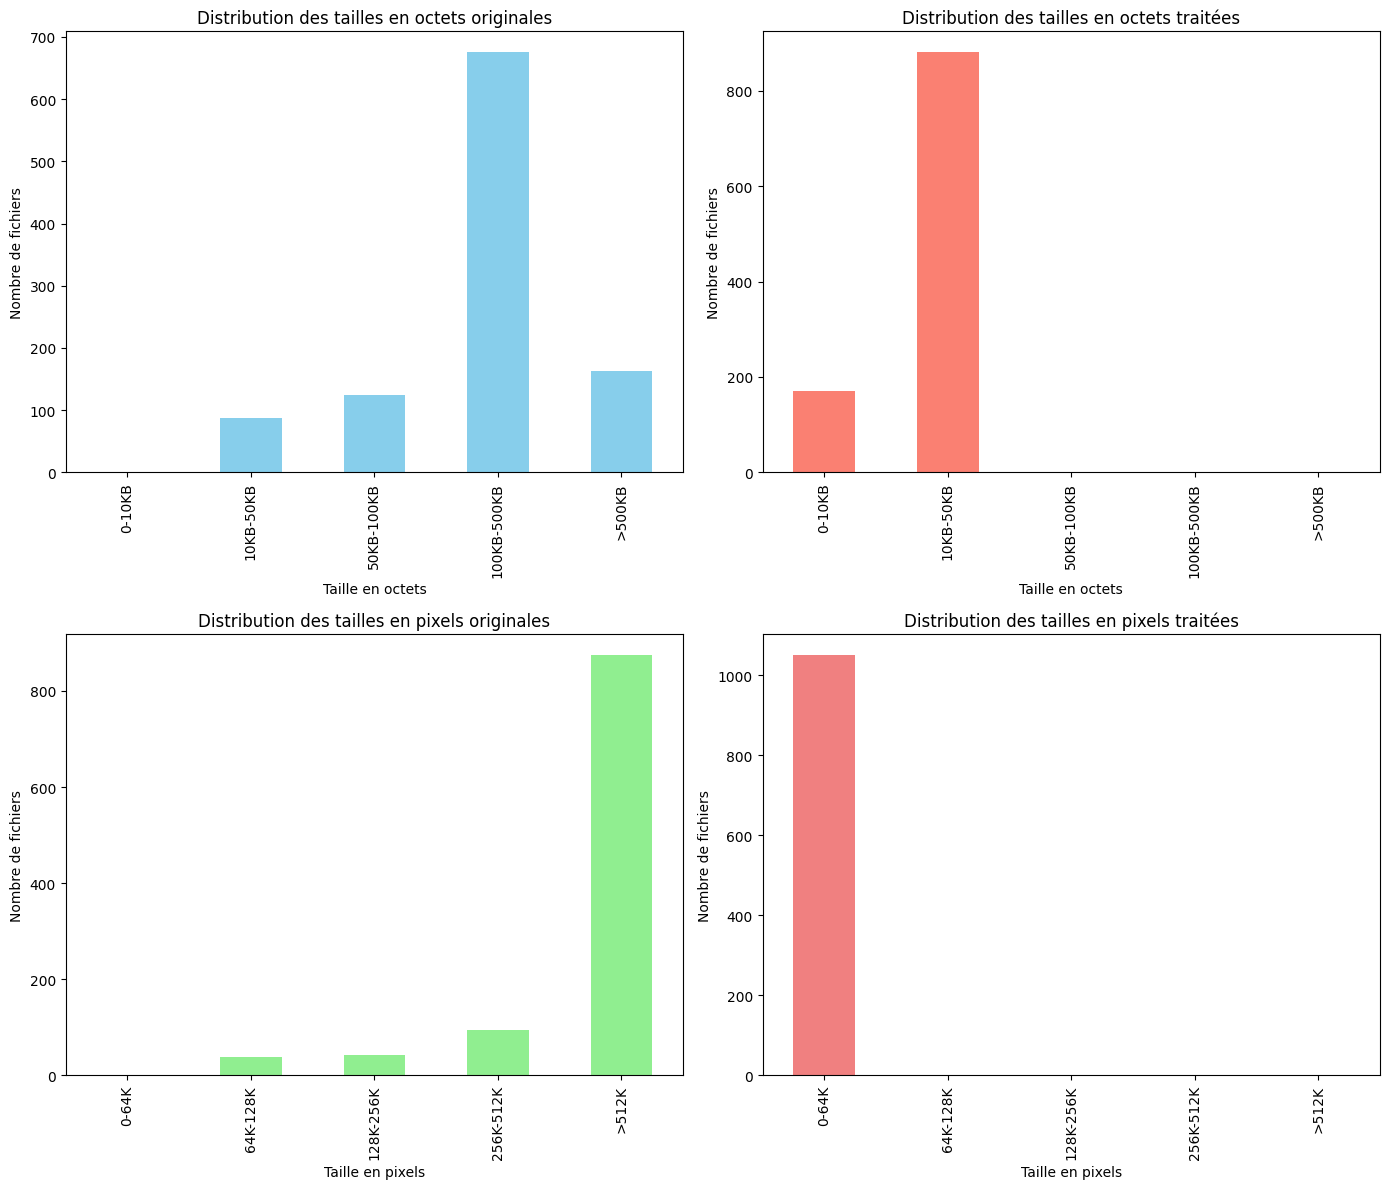

In [ ]:
# Obtenir les tailles des fichiers dans les répertoires
original_sizes = get_file_sizes(path)
processed_sizes = get_file_sizes(new_path)

# Convertir en DataFrame
df_original = pd.DataFrame(original_sizes)
df_processed = pd.DataFrame(processed_sizes)

# Créer des bins pour la taille en octets
byte_bins = [0, 10**4, 5*10**4, 10**5, 5*10**5, float('inf')]
byte_labels = ['0-10KB', '10KB-50KB', '50KB-100KB', '100KB-500KB', '>500KB']

# Créer des bins pour la taille en pixels
pixel_bins = [0, 64*1024, 128*1024, 256*1024, 512*1024, float('inf')]
pixel_labels = ['0-64K', '64K-128K', '128K-256K', '256K-512K', '>512K']

# Ajouter des colonnes pour les bins
df_original['size_bin'] = pd.cut(df_original['size_bytes'], bins=byte_bins, labels=byte_labels)
df_processed['size_bin'] = pd.cut(df_processed['size_bytes'], bins=byte_bins, labels=byte_labels)
df_original['pixel_bin'] = pd.cut(df_original['size_pixels'], bins=pixel_bins, labels=pixel_labels)
df_processed['pixel_bin'] = pd.cut(df_processed['size_pixels'], bins=pixel_bins, labels=pixel_labels)

# Tracer les histogrammes
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Distribution des tailles en octets originales
df_original['size_bin'].value_counts().sort_index().plot(kind='bar', ax=axs[0, 0], color='skyblue')
axs[0, 0].set_title('Distribution des tailles en octets originales')
axs[0, 0].set_xlabel('Taille en octets')
axs[0, 0].set_ylabel('Nombre de fichiers')

# Distribution des tailles en octets traitées
df_processed['size_bin'].value_counts().sort_index().plot(kind='bar', ax=axs[0, 1], color='salmon')
axs[0, 1].set_title('Distribution des tailles en octets traitées')
axs[0, 1].set_xlabel('Taille en octets')
axs[0, 1].set_ylabel('Nombre de fichiers')

# Distribution des tailles en pixels originales
df_original['pixel_bin'].value_counts().sort_index().plot(kind='bar', ax=axs[1, 0], color='lightgreen')
axs[1, 0].set_title('Distribution des tailles en pixels originales')
axs[1, 0].set_xlabel('Taille en pixels')
axs[1, 0].set_ylabel('Nombre de fichiers')

# Distribution des tailles en pixels traitées
df_processed['pixel_bin'].value_counts().sort_index().plot(kind='bar', ax=axs[1, 1], color='lightcoral')
axs[1, 1].set_title('Distribution des tailles en pixels traitées')
axs[1, 1].set_xlabel('Taille en pixels')
axs[1, 1].set_ylabel('Nombre de fichiers')

plt.tight_layout()
plt.show()

Catégorie: Baby Care


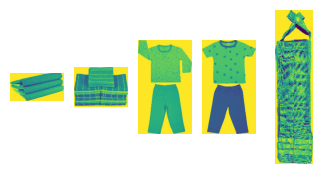

Catégorie: Beauty and Personal Care


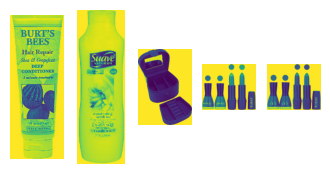

Catégorie: Computers


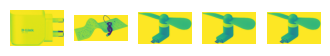

Catégorie: Home Decor & Festive Needs


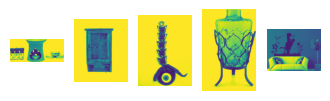

Catégorie: Home Furnishing


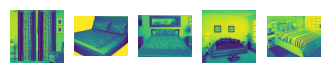

Catégorie: Kitchen & Dining


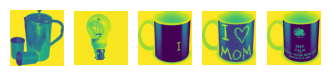

Catégorie: Watches


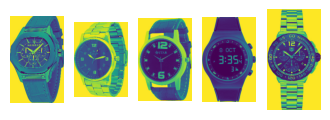

In [ ]:
show_cat_img(df, new_path, 'cat_1', 5)

## Test : Détermination & affichage des descripteurs SIFT

In [ ]:
list_photos = new_path + df_label['image']
print(len(list_photos))
print(list_photos[0])

1050
/content/drive/MyDrive/Colab Notebooks/p6/data/Images_process/55b85ea15a1536d46b7190ad6fff8ce7.jpg


### Descripteurs : filtres basiques

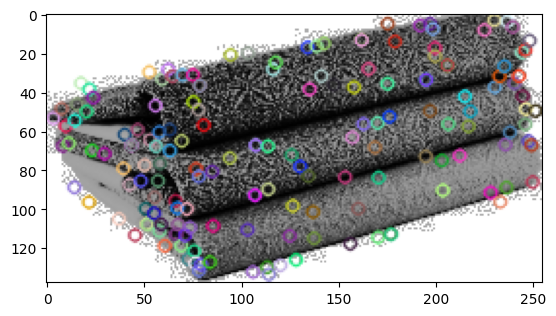

Descripteurs :  (171, 128)

[[  3.   1.   0. ...   0.   0.   0.]
 [  1.   7.  39. ...   0.   0.  41.]
 [ 11.  33.  19. ...   7.   9.  81.]
 ...
 [  0.   0.   0. ...   0.   0.   0.]
 [ 10.  11.   8. ...  14.  58.  38.]
 [124.  89.   7. ...   0.   7.  12.]]


In [ ]:
# https://github.com/opencv/opencv/issues/16736
sift = cv2.SIFT_create()
image = cv2.imread(list_photos[1],0) # convert in gray
image = cv2.equalizeHist(image)   # equalize image histogram

kp, des = sift.detectAndCompute(image, None)
img=cv2.drawKeypoints(image,kp,image)
plt.imshow(img)
plt.show()
print("Descripteurs : ", des.shape)
print()
print(des)

### Descripteurs : ajout de filtres

In [ ]:
sift_descriptors = 150
blur_kernel_size = 5

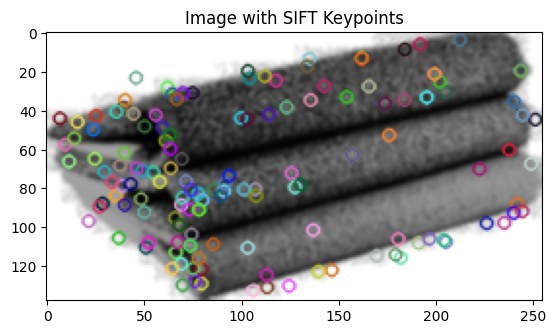

Descripteurs :  (150, 128)

[[ 46.  30.   1. ...   3.  60.  37.]
 [ 30. 177.  15. ...   0.   0.   0.]
 [  0.   8.  30. ...   0.   0.   0.]
 ...
 [ 40.  35.   2. ...   0.   0.   6.]
 [ 91.  35.   1. ...   7.   3.   6.]
 [  0.   0.   0. ...   0.   0.   3.]]


In [ ]:
# Initialiser SIFT
sift = cv2.SIFT_create(sift_descriptors)

image = cv2.imread(list_photos[1], 0)
image = cv2.equalizeHist(image) # Égaliser l'histogramme de l'image
image = image.astype(np.float32) / 255.0 # Normaliser l'image
image = cv2.GaussianBlur(image, (blur_kernel_size, blur_kernel_size), 0) # Appliquer un flou gaussien

# Convertir l'image en uint8 pour SIFT
image = (image * 255).astype(np.uint8)

# Détecter les points clés et calculer les descripteurs
kp, des = sift.detectAndCompute(image, None)

# Dessiner les points clés sur l'image
img = cv2.drawKeypoints(image, kp, image)

# Afficher l'image avec les points clés
plt.imshow(img, cmap='gray')
plt.title('Image with SIFT Keypoints')
plt.show()

# Afficher les informations sur les descripteurs
print("Descripteurs : ", des.shape)
print()
print(des)

## Modèlisation SIFT

### Extraction de features + réduction PCA + T-SNE

In [ ]:
list_photos

NameError: name 'list_photos' is not defined

In [ ]:
# Décorateur pour mesurer le temps d'exécution
def timer_decorator(func):
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        start_time = time.time()  # Enregistrer le temps de début
        result = func(*args, **kwargs)  # Exécuter la fonction
        end_time = time.time()  # Enregistrer le temps de fin
        elapsed_time = end_time - start_time  # Calculer le temps écoulé
        print(f"Temps d'exécution de {func.__name__}: {elapsed_time:.4f} secondes")
        return result
    return wrapper

# Décorateur pour mesurer le temps total
def total_time_decorator(func):
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        wrapper.total_start_time = time.time()  # Enregistrer le temps de début total
        result = func(*args, **kwargs)  # Exécuter la fonction
        wrapper.total_end_time = time.time()  # Enregistrer le temps de fin total
        total_elapsed_time = wrapper.total_end_time - wrapper.total_start_time  # Calculer le temps total écoulé
        print(f"Temps total d'exécution: {total_elapsed_time:.4f} secondes")
        return result
    return wrapper

In [ ]:
@total_time_decorator
def process_images(new_path, df_label, category, sift_descriptors):
    # Liste pour stocker tous les descripteurs
    all_descriptors = []
    image_features = []
    labels = []

    @timer_decorator
    def extract_sift_features(sift_descriptors):
        nonlocal all_descriptors, image_features, labels
        sift = cv2.SIFT_create(sift_descriptors)
        for index, row in df_label.iterrows():
            image_path = os.path.join(new_path, row['image'])
            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            image = cv2.equalizeHist(image)   # equalize image histogram
            image = image.astype(np.float32) / 255.0   # Normaliser l'image
            blur_kernel_size = 5
            image = cv2.GaussianBlur(image, (blur_kernel_size, blur_kernel_size), 0) # Appliquer un flou gaussien

            # Convertir l'image en uint8 pour SIFT
            image = (image * 255).astype(np.uint8)
            _, descriptors = sift.detectAndCompute(image, None)
            if descriptors is not None:
                all_descriptors.append(descriptors)
                image_features.append(descriptors.mean(axis=0))  # Utiliser la moyenne comme feature
                labels.append(row[category])

    @timer_decorator
    def create_clusters():
        nonlocal all_descriptors
        # Concaténer tous les descripteurs en un seul tableau
        all_descriptors = np.concatenate(all_descriptors, axis=0)
        # Créer des clusters de descripteurs avec K-means
        num_clusters = 50
        kmeans = KMeans(n_clusters=num_clusters)
        kmeans.fit(all_descriptors)
        return kmeans, num_clusters

    @timer_decorator
    def create_image_histograms(kmeans, num_clusters):
        nonlocal all_descriptors, image_features
        visual_words = kmeans.predict(all_descriptors)
        image_histograms = np.zeros((len(image_features), num_clusters), dtype=np.float32)
        start = 0
        for i, descriptors in enumerate(all_descriptors):
            length = len(descriptors)
            histogram = np.bincount(visual_words[start:start + length], minlength=num_clusters)
            if i < len(image_features):  # Vérifier que l'index est valide
                image_histograms[i] = histogram
            start += length
        return image_histograms

    @timer_decorator
    def reduce_dimensions(image_histograms):
        # Réduction de dimension avec PCA
        pca = PCA(n_components=50)
        reduced_features = pca.fit_transform(image_histograms)
        # Réduction de dimension avec t-SNE pour la visualisation
        tsne = TSNE(n_components=2)
        tsne_results = tsne.fit_transform(reduced_features)
        return tsne_results

    @timer_decorator
    def plot_results(tsne_results, labels):
        # Visualisation des résultats t-SNE
        plt.figure(figsize=(10, 6))
        unique_labels = np.unique(labels)
        colors = plt.cm.get_cmap("hsv", len(unique_labels))
        for i, label in enumerate(unique_labels):
            idx = np.array(labels) == label
            plt.scatter(tsne_results[idx, 0], tsne_results[idx, 1], label=label, color=colors(i), s=5)
        plt.title('t-SNE Visualization of Image Features with Classes')
        plt.xlabel('t-SNE Component 1')
        plt.ylabel('t-SNE Component 2')
        plt.legend()
        plt.show()

    # Exécuter les étapes
    extract_sift_features(sift_descriptors)
    kmeans, num_clusters = create_clusters()
    image_histograms = create_image_histograms(kmeans, num_clusters)
    tsne_results = reduce_dimensions(image_histograms)
    plot_results(tsne_results, labels)

### Exécution SIFT / T-SNE

#### 1ère catégorie, 200 descripteurs /img

Temps d'exécution de extract_sift_features: 38.3319 secondes
Temps d'exécution de create_clusters: 15.6313 secondes
Temps d'exécution de create_image_histograms: 0.2587 secondes
Temps d'exécution de reduce_dimensions: 8.6806 secondes


<ipython-input-43-2a7e9f2a53eb>:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("hsv", len(unique_labels))


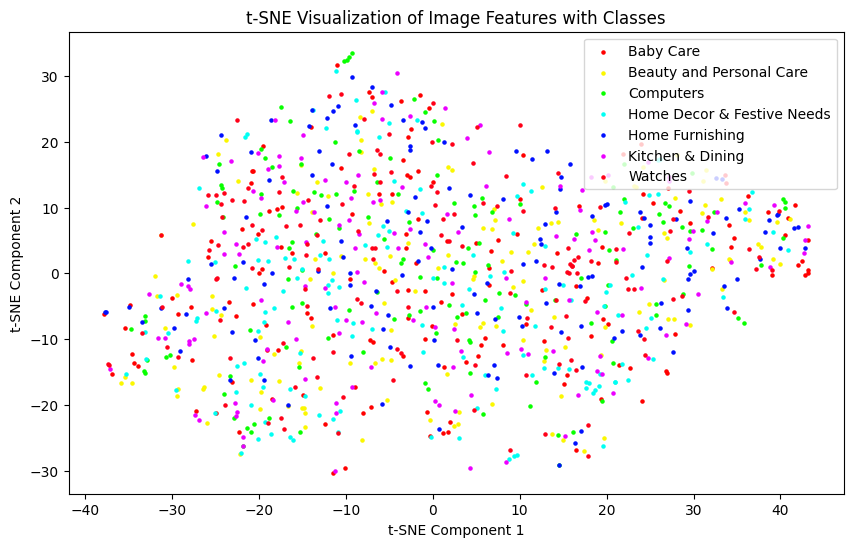

Temps d'exécution de plot_results: 0.4639 secondes
Temps total d'exécution: 63.3687 secondes


In [ ]:
# Appeler la fonction principale
process_images(new_path, df_label, 'cat_1', 200)

#### 2ère catégorie, 200 descripteurs /img

In [ ]:
df_label_cat2 = df[['image', 'description','cat_2']].copy()

le = preprocessing.LabelEncoder()
df_label_cat2["label"] = le.fit_transform(df_label_cat2["cat_2"])

df_label_cat2.head(3)

,image,description,cat_2,label
0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,Key Features of Elegance Polyester Multicolor ...,Curtains & Accessories,19
1,7b72c92c2f6c40268628ec5f14c6d590.jpg,Specifications of Sathiyas Cotton Bath Towel (...,Baby Bath & Skin,1
2,64d5d4a258243731dc7bbb1eef49ad74.jpg,Key Features of Eurospa Cotton Terry Face Towe...,Baby Bath & Skin,1


Temps d'exécution de extract_sift_features: 25.4148 secondes
Temps d'exécution de create_clusters: 14.8757 secondes
Temps d'exécution de create_image_histograms: 0.4914 secondes
Temps d'exécution de reduce_dimensions: 8.0140 secondes


<ipython-input-43-2a7e9f2a53eb>:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("hsv", len(unique_labels))


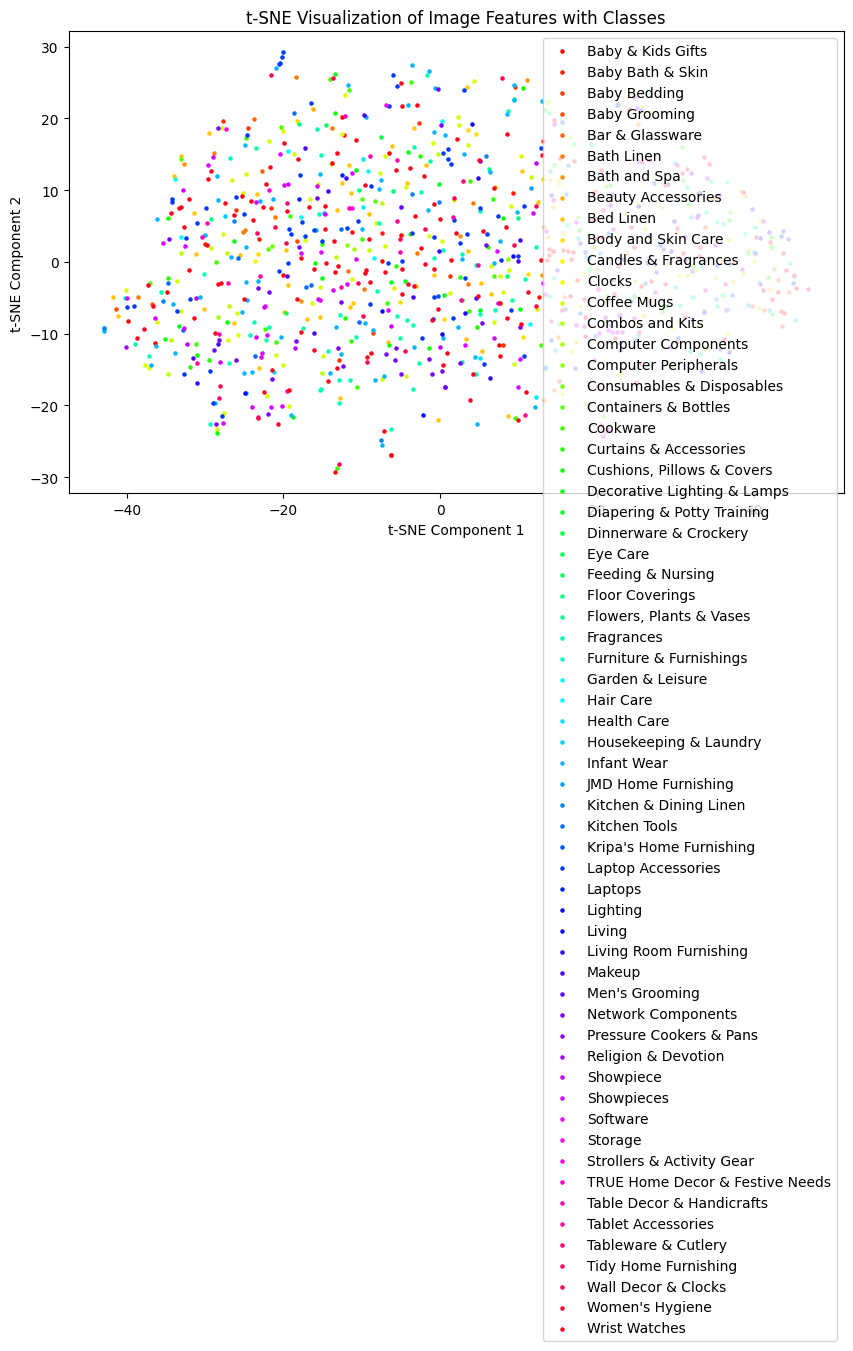

Temps d'exécution de plot_results: 1.2851 secondes
Temps total d'exécution: 50.0833 secondes


In [ ]:
process_images(new_path, df_label_cat2, 'cat_2', 200)

#### Conclusion SIFT

Résultats => patchwork de points : peu de résultats interprétables après une première passe.

En l'état non utilisable.

# Modèle CNN : étude de faisabilité

## VGG16

### Création du modèle pré-entraîné

In [13]:
base_model = VGG16()
model = Model(inputs=base_model.inputs, outputs=base_model.layers[-2].output)

print(model.summary())

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

None


### Création des features des images

In [14]:
path

'/content/drive/MyDrive/Colab Notebooks/p6/data/Images/'

In [32]:
images_features = []
i=0
for image_file in df["image"] :
    if i%100 == 0 : print(i)
    i +=1
    image = load_img(path + image_file, target_size=(224, 224))
    image = img_to_array(image)
    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)
    images_features.append(model.predict(image, verbose=0)[0]) # predict from pretrained model

images_features = np.asarray(images_features)
images_features.shape

0
100
200
300
400
500
600


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


700
800
900
1000


(1050, 4096)

### Réduction dimension et analyse

#### Réduction de dimension PCA

In [33]:
print(images_features.shape)
pca = decomposition.PCA(n_components=0.99)
feat_pca= pca.fit_transform(images_features)
print(feat_pca.shape)

(1050, 4096)
(1050, 803)


#### Réduction de dimension T-SNE et affichage des images selon vraies classes

In [34]:
temps1 = time.time()

tsne = manifold.TSNE(n_components=2, perplexity=30, max_iter=2000, init='random', random_state=42)
X_tsne = tsne.fit_transform(feat_pca)

duration1=time.time()-temps1
print("temps de T-SNE : ", "%15.2f" % duration1, "secondes")

temps de T-SNE :            13.46 secondes


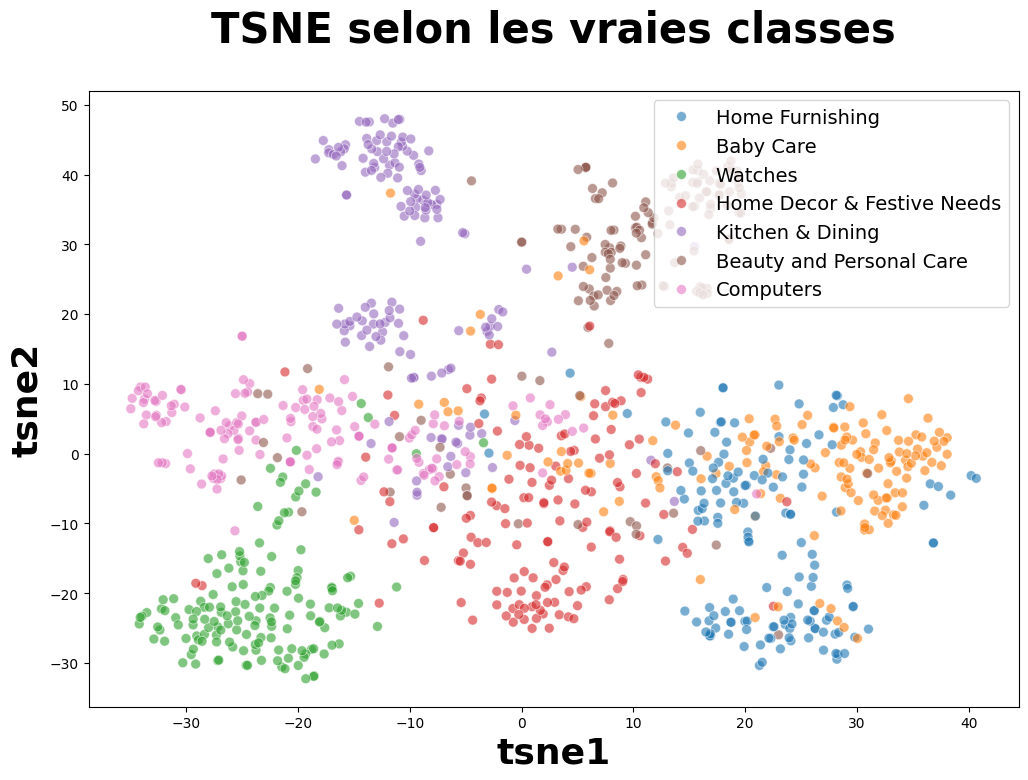

In [35]:
df_tsne = pd.DataFrame(X_tsne, columns=['tsne1', 'tsne2'])
df_tsne["class"] = df["cat_1"]

class_count = len(df_tsne["class"].unique())

plt.figure(figsize=(12,8))
sns.scatterplot(
    x="tsne1", y="tsne2",
    hue="class",
    palette=sns.color_palette('tab10', n_colors=class_count), s=50, alpha=0.6,
    data=df_tsne,
    legend="brief")

plt.title('TSNE selon les vraies classes', fontsize = 30, pad = 35, fontweight = 'bold')
plt.xlabel('tsne1', fontsize = 26, fontweight = 'bold')
plt.ylabel('tsne2', fontsize = 26, fontweight = 'bold')
plt.legend(prop={'size': 14})

plt.show()

#### Création de clusters à partir du T-SNE et affichage des images selon clusters

In [ ]:
df_label.head(2)

,image,description,cat_1,label
0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,Key Features of Elegance Polyester Multicolor ...,Home Furnishing,4
1,7b72c92c2f6c40268628ec5f14c6d590.jpg,Specifications of Sathiyas Cotton Bath Towel (...,Baby Care,0


In [ ]:
class_count

7

In [ ]:
cls = cluster.KMeans(n_clusters=class_count, n_init=100)
cls.fit(X_tsne)

KMeans(n_clusters=7, n_init=100)

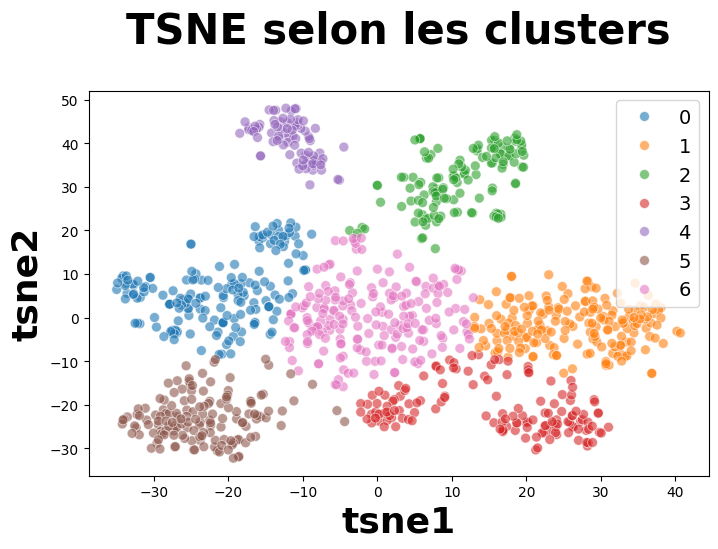

ARI :  0.4511049950347458


In [ ]:
df_tsne["cluster"] = cls.labels_

plt.figure(figsize=(8,5))
sns.scatterplot(
    x="tsne1", y="tsne2",
    hue="cluster",
    palette=sns.color_palette('tab10', n_colors=class_count), s=50, alpha=0.6,
    data=df_tsne,
    legend="brief")

plt.title('TSNE selon les clusters', fontsize = 30, pad = 35, fontweight = 'bold')
plt.xlabel('tsne1', fontsize = 26, fontweight = 'bold')
plt.ylabel('tsne2', fontsize = 26, fontweight = 'bold')
plt.legend(prop={'size': 14})

plt.show()

labels = df_label["label"]
print("ARI : ", metrics.adjusted_rand_score(labels, cls.labels_))

In [ ]:
df_label["label"].unique()

array([4, 0, 6, 3, 5, 1, 2])

In [ ]:
labels_info = df_label[["label","cat_1"]]\
            .drop_duplicates().sort_values(by=['label'], ascending=True)\
            .reset_index(drop=True)

print(labels_info.to_string(index=False))

 label                      cat_1
     0                  Baby Care
     1   Beauty and Personal Care
     2                  Computers
     3 Home Decor & Festive Needs
     4            Home Furnishing
     5           Kitchen & Dining
     6                    Watches


In [ ]:
labels_info_tsne = df_tsne[["cluster","class"]]\
            .drop_duplicates().sort_values(by=['cluster'], ascending=True)\
            .reset_index(drop=True)

print(labels_info_tsne.to_string(index=False))

 cluster                      class
       0                    Watches
       0           Kitchen & Dining
       0                  Computers
       0   Beauty and Personal Care
       0 Home Decor & Festive Needs
       0                  Baby Care
       1                  Baby Care
       1 Home Decor & Festive Needs
       1   Beauty and Personal Care
       1                  Computers
       1           Kitchen & Dining
       1            Home Furnishing
       2 Home Decor & Festive Needs
       2   Beauty and Personal Care
       2           Kitchen & Dining
       2                  Baby Care
       3 Home Decor & Festive Needs
       3                  Baby Care
       3   Beauty and Personal Care
       3            Home Furnishing
       4           Kitchen & Dining
       4   Beauty and Personal Care
       4                  Baby Care
       5                    Watches
       5                  Baby Care
       5 Home Decor & Festive Needs
       5                  Co

In [ ]:
# Analyse d'image "Computers" affectées au cluster 4 "Home Furnishing"

list_computers_0 = [i for i in range(len(df["image"])) \
                if (df.iloc[i]['cat_1']=='Computers') and (df_tsne.iloc[i]['cluster']== 2)]
id_to_show = list_computers_0[0]

print(len(list_computers_0))
print(id_to_show)

IndexError: list index out of range

In [ ]:
# Affichage image "Computers" considérée comme "Home Furnishing"
print(df_tsne.iloc[id_to_show])
fig = plt.figure(figsize = (8, 5))
# plt.subplot(130 + 1 + i)
filename = path + df["image"][id_to_show]
image = imread(filename)
plt.imshow(image)
plt.show()

NameError: name 'id_to_show' is not defined

#### Analyse par classes

In [ ]:
conf_mat = metrics.confusion_matrix(labels, cls.labels_)
print(conf_mat)

[[  1 109   4   8   1   1  26]
 [  8   4 117   6   1   0  14]
 [109   1   0   0   0   1  39]
 [  5   2   1  53   0   8  81]
 [  0  70   0  75   0   0   5]
 [ 35   1   6   0  78   0  30]
 [ 13   0   0   0   0 135   2]]


In [ ]:
def conf_mat_transform(y_true,y_pred) :
    conf_mat = metrics.confusion_matrix(y_true,y_pred)

    corresp = np.argmax(conf_mat, axis=0)
    print ("Correspondance des clusters : ", corresp)
    # y_pred_transform = np.apply_along_axis(correspond_fct, 1, y_pred)
    labels = pd.Series(y_true, name="y_true").to_frame()
    labels['y_pred'] = y_pred
    labels['y_pred_transform'] = labels['y_pred'].apply(lambda x : corresp[x])

    return labels['y_pred_transform'], corresp

In [ ]:
cls_labels_transform, corresp = conf_mat_transform(labels, cls.labels_)
conf_mat = metrics.confusion_matrix(labels, cls_labels_transform)
print(conf_mat)
print()
print(metrics.classification_report(labels, cls_labels_transform))

Correspondance des clusters :  [2 0 1 4 5 6 3]
[[109   4   1  26   8   1   1]
 [  4 117   8  14   6   1   0]
 [  1   0 109  39   0   0   1]
 [  2   1   5  81  53   0   8]
 [ 70   0   0   5  75   0   0]
 [  1   6  35  30   0  78   0]
 [  0   0  13   2   0   0 135]]

              precision    recall  f1-score   support

           0       0.58      0.73      0.65       150
           1       0.91      0.78      0.84       150
           2       0.64      0.73      0.68       150
           3       0.41      0.54      0.47       150
           4       0.53      0.50      0.51       150
           5       0.97      0.52      0.68       150
           6       0.93      0.90      0.92       150

    accuracy                           0.67      1050
   macro avg       0.71      0.67      0.68      1050
weighted avg       0.71      0.67      0.68      1050



In [ ]:
list_labels = labels_info.cat_1.unique()
list_labels

array(['Baby Care', 'Beauty and Personal Care', 'Computers',
       'Home Decor & Festive Needs', 'Home Furnishing',
       'Kitchen & Dining', 'Watches'], dtype=object)

<Axes: >

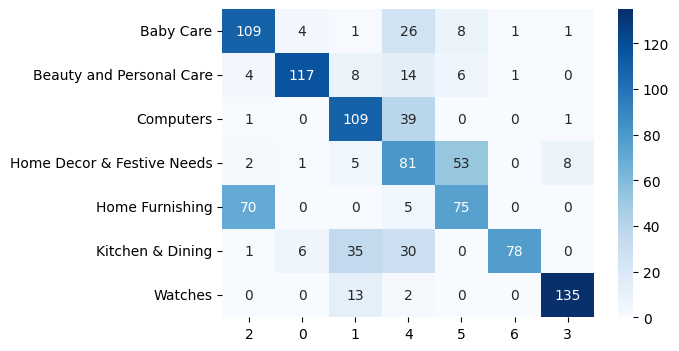

In [ ]:
df_cm = pd.DataFrame(conf_mat, index = [label for label in list_labels],
                  columns = [i for i in corresp])
plt.figure(figsize = (6,4))
sns.heatmap(df_cm, annot=True, fmt='d', cmap="Blues")

#### check label vs cluster images

##### Exploration

In [ ]:
def display_images_from_cluster(df, df_tsne, cluster_num, path, num_images=5):
    # Filtrer les IDs des images appartenant au cluster spécifié
    list_images_in_cluster = [
        i for i in range(len(df["image"]))
        if df_tsne.iloc[i]['cluster'] == cluster_num
    ]

    # Sélectionner les premiers `num_images` IDs
    ids_to_show = list_images_in_cluster[:num_images]

    # Afficher les images
    plt.figure(figsize=(8, 4))
    for i, idx in enumerate(ids_to_show):
        plt.subplot(1, num_images, i + 1)
        filename = path + df["image"][idx]
        image = imread(filename)
        plt.imshow(image)
        # Ajouter le nom de la classe dans le titre
        class_name = df.iloc[idx]['cat_1']
        plt.title(f"ID: {idx}\nCluster: {cluster_num}\nClass: {class_name}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

<Axes: >

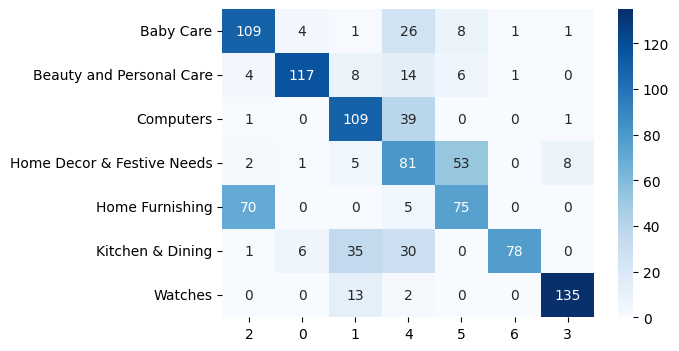

In [ ]:
df_cm = pd.DataFrame(conf_mat, index = [label for label in list_labels],
                  columns = [i for i in corresp])
plt.figure(figsize = (6,4))
sns.heatmap(df_cm, annot=True, fmt='d', cmap="Blues")

In [ ]:
path

'/content/drive/MyDrive/Colab Notebooks/p6/data/Images/'

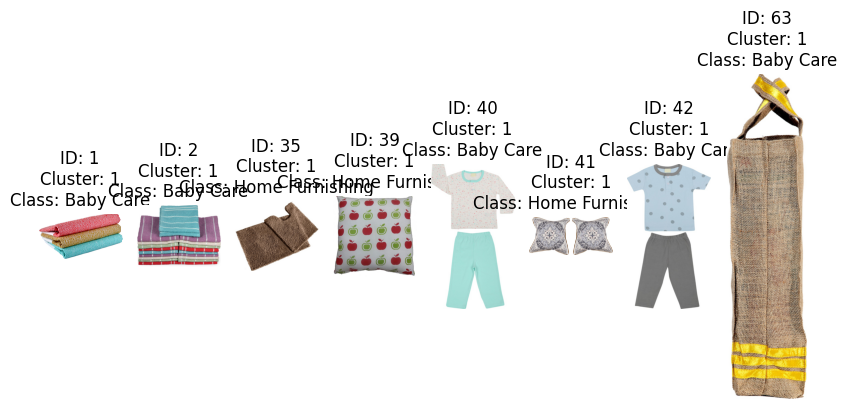

In [ ]:
display_images_from_cluster(df, df_tsne, cluster_num=1, path=path, num_images=8)

Affichage des images pour le cluster 1:


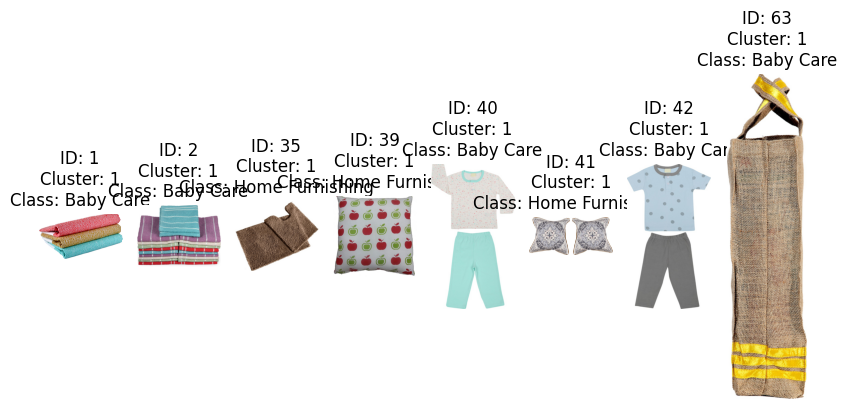

Affichage des images pour le cluster -1:


<Figure size 800x400 with 0 Axes>

Affichage des images pour le cluster 0:


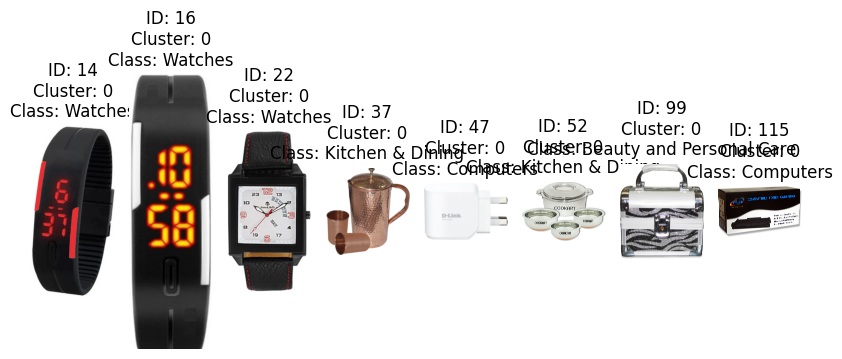

Affichage des images pour le cluster 3:


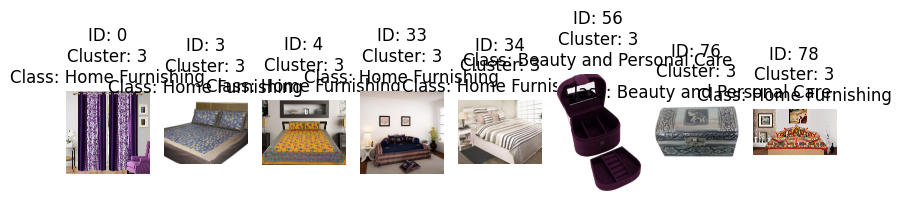

Affichage des images pour le cluster 4:


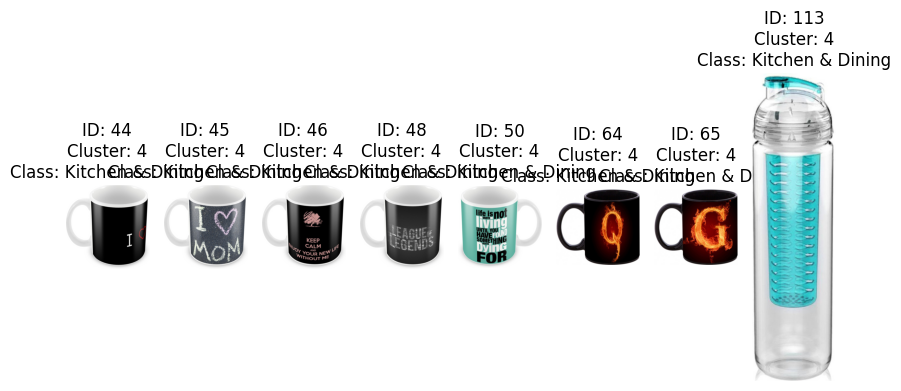

Affichage des images pour le cluster 5:


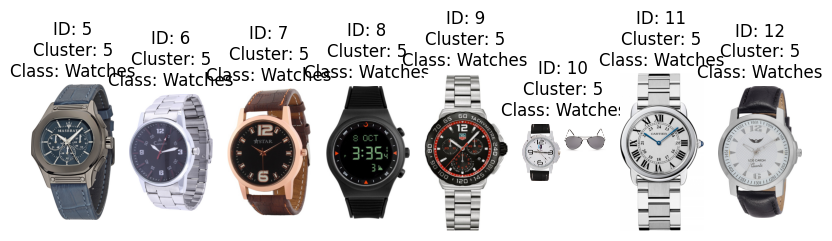

Affichage des images pour le cluster 2:


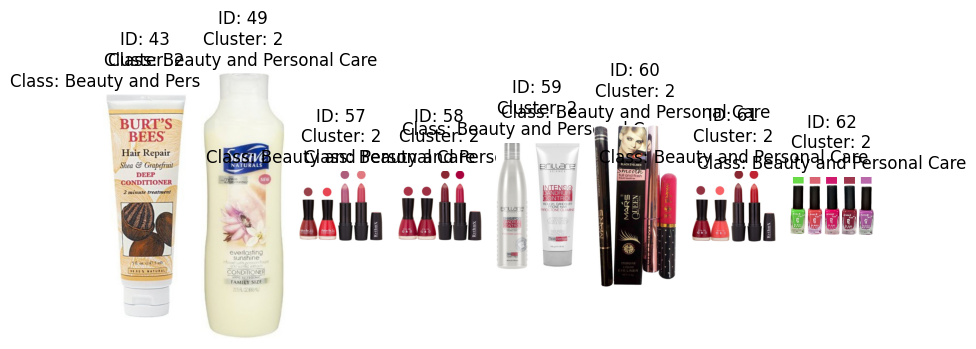

In [ ]:
for cluster_num in corresp:
    cluster_num = int(cluster_num) - 1
    print(f"Affichage des images pour le cluster {cluster_num}:")
    display_images_from_cluster(df, df_tsne, cluster_num=int(cluster_num), path=path, num_images=8)


In [ ]:
list_labels

array(['Baby Care', 'Beauty and Personal Care', 'Computers',
       'Home Decor & Festive Needs', 'Home Furnishing',
       'Kitchen & Dining', 'Watches'], dtype=object)

In [ ]:
concatenated_string = '1234567'

In [ ]:
most_frequent_classes = []

for cluster_num in concatenated_string:
    cluster_index = int(cluster_num) - 1
    classes_in_cluster = df_tsne[df_tsne['cluster'] == cluster_index]['class'].value_counts()
    most_frequent_class = classes_in_cluster.idxmax()
    most_frequent_classes.append(most_frequent_class)

print("Classes les plus fréquentes pour chaque cluster :")
print(most_frequent_classes)

Classes les plus fréquentes pour chaque cluster :
['Computers', 'Baby Care', 'Beauty and Personal Care', 'Home Furnishing', 'Kitchen & Dining', 'Watches', 'Home Decor & Festive Needs']


In [ ]:
for cluster_num in concatenated_string:
    cluster_index = int(cluster_num) - 1
    print(cluster_index)

0
1
2
3
4
5
6


In [ ]:
def class_searching(df, class_search):
    index_class_search = most_frequent_classes.index(class_search)
    classes_in_cluster = df[df['cluster'] == index_class_search]['class'].value_counts()

    print(f'search input: {class_search}')
    print(f'class found: {index_class_search}\n')
    print(classes_in_cluster)

    return index_class_search

In [ ]:
class_searching(df_tsne, 'Watches')

search input: Watches
class found: 5

class
Watches                       135
Home Decor & Festive Needs      8
Baby Care                       1
Computers                       1
Name: count, dtype: int64


5

In [ ]:
df_tsne[['class', 'cluster']].value_counts()[:8]

class                       cluster
Watches                     5          135
Beauty and Personal Care    2          117
Computers                   0          109
Baby Care                   1          109
Home Decor & Festive Needs  6           81
Kitchen & Dining            4           78
Home Furnishing             3           75
                            1           70
Name: count, dtype: int64

In [ ]:
top_classes = df_tsne[['class', 'cluster']].value_counts()[:8]
top_classes_df = top_classes.reset_index()

# Renommer la colonne des valeurs
top_classes_df.columns = ['class', 'cluster', 'count']

# Ordonner par la colonne 'cluster' de manière ascendante
sorted_result_df = top_classes_df.sort_values(by='cluster')

# Afficher le résultat
print(sorted_result_df)

                        class  cluster  count
2                   Computers        0    109
3                   Baby Care        1    109
7             Home Furnishing        1     70
1    Beauty and Personal Care        2    117
6             Home Furnishing        3     75
5            Kitchen & Dining        4     78
0                     Watches        5    135
4  Home Decor & Festive Needs        6     81


In [ ]:
most_frequent_classes

['Computers',
 'Baby Care',
 'Beauty and Personal Care',
 'Home Furnishing',
 'Kitchen & Dining',
 'Watches',
 'Home Decor & Festive Needs']

In [ ]:
class_search = 'Beauty and Personal Care'

In [ ]:
index_class_search = class_searching(df_tsne, class_search)
print(index_class_search)

search input: Beauty and Personal Care
class found: 2

class
Beauty and Personal Care      117
Kitchen & Dining                6
Baby Care                       4
Home Decor & Festive Needs      1
Name: count, dtype: int64
2


In [ ]:
cluster_target = 'Kitchen & Dining'
index_class_search = class_searching(df_tsne, 'Kitchen & Dining')

search input: Kitchen & Dining
class found: 4

class
Kitchen & Dining            78
Beauty and Personal Care     1
Baby Care                    1
Name: count, dtype: int64


In [ ]:
list_computers_0 = [i for i in range(len(df["image"])) \
                if (df.iloc[i]['cat_1']==class_search) and (df_tsne.iloc[i]['cluster']== index_class_search)]
id_to_show = list_computers_0[0]

print(len(list_computers_0))
print(id_to_show)

1
125


In [ ]:
df_tsne.iloc[id_to_show]

,125
tsne1,-4.482441
tsne2,39.096958
class,Beauty and Personal Care
cluster,2


In [ ]:
print(f"Analyse d'image '{class_search}' affectées au cluster '{cluster_target}'")

Analyse d'image 'Beauty and Personal Care' affectées au cluster 'Kitchen & Dining'


tsne1                     -4.482441
tsne2                     39.096958
class      Beauty and Personal Care
cluster                           2
Name: 125, dtype: object


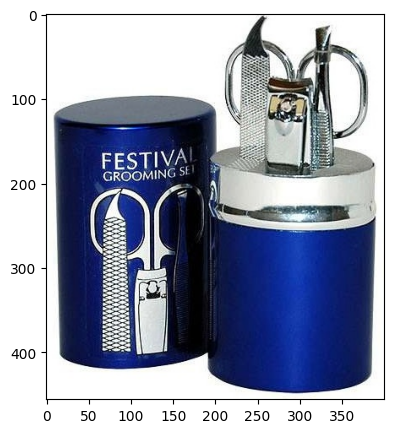

In [ ]:
print(df_tsne.iloc[id_to_show])
fig = plt.figure(figsize = (8, 5))
# plt.subplot(130 + 1 + i)
filename = path + df["image"][id_to_show]
image = imread(filename)
plt.imshow(image)
plt.show()

##### Consolidation heatmap

ARI :  0.4511049950347458
Correspondance des clusters :  [4 2 5 6 1 0 3]


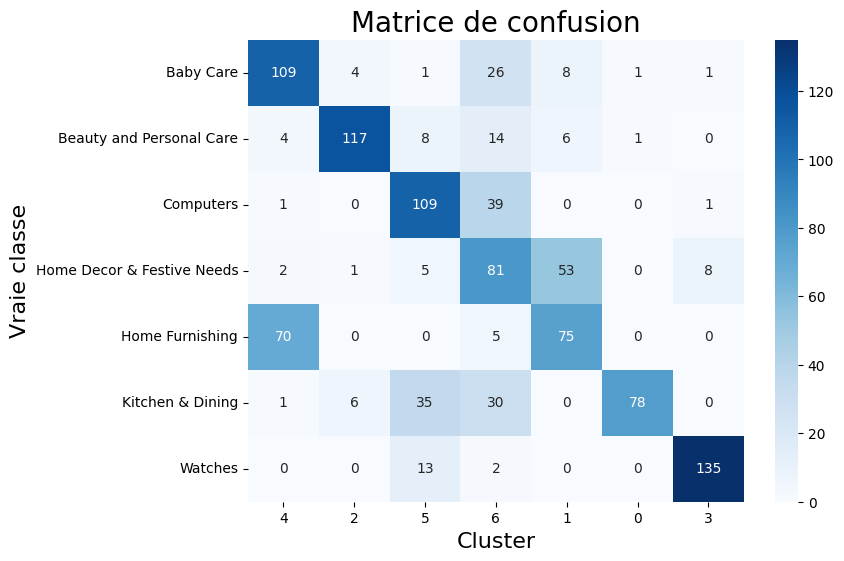

 label                      cat_1
     0                  Baby Care
     1   Beauty and Personal Care
     2                  Computers
     3 Home Decor & Festive Needs
     4            Home Furnishing
     5           Kitchen & Dining
     6                    Watches


In [ ]:
# Vérification labels bien triés
labels_info = df_label[["label", "cat_1"]].drop_duplicates().sort_values(by=['label'], ascending=True).reset_index(drop=True)

# Obtenir la liste des labels triés
list_labels = labels_info['cat_1'].unique()

# Appliquer KMeans sur les données t-SNE
cls = KMeans(n_clusters=len(list_labels), n_init=100, random_state=42)
cls.fit(X_tsne)

# Ajout les clusters au DataFrame t-SNE
df_tsne["cluster"] = cls.labels_

# Calcul le score ARI
ari_score = metrics.adjusted_rand_score(df_label["label"], cls.labels_)
print("ARI : ", ari_score)

# Afficher la matrice de confusion
conf_mat = metrics.confusion_matrix(df_label["label"], cls.labels_)

# Fonction pour transformer les clusters en labels correspondants
def conf_mat_transform(y_true, y_pred):
    conf_mat = metrics.confusion_matrix(y_true, y_pred)
    corresp = np.argmax(conf_mat, axis=0)
    print("Correspondance des clusters : ", corresp)

    labels = pd.Series(y_true, name="y_true").to_frame()
    labels['y_pred'] = y_pred
    labels['y_pred_transform'] = labels['y_pred'].apply(lambda x: corresp[x])

    return labels['y_pred_transform'], corresp

# Transformer les clusters en labels correspondants
cls_labels_transform, corresp = conf_mat_transform(df_label["label"], cls.labels_)
conf_mat_transformed = metrics.confusion_matrix(df_label["label"], cls_labels_transform)

# Créer un DataFrame pour la matrice de confusion avec les labels triés
df_cm = pd.DataFrame(conf_mat_transformed, index=[label for label in list_labels], columns=[i for i in corresp])

# Afficher la heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_cm, annot=True, fmt='d', cmap="Blues")
plt.title('Matrice de confusion', fontsize=20)
plt.xlabel('Cluster', fontsize=16)
plt.ylabel('Vraie classe', fontsize=16)
plt.show()

# Afficher les informations sur les labels
print(labels_info.to_string(index=False))


## Classification Supervisée

### Train Test Val Split + Stratify

In [16]:
df.head(3)

,uniq_id,product_name,product_category_tree,image,description,brand,cat_1,cat_2,cat_3
0,55b85ea15a1536d46b7190ad6fff8ce7,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",55b85ea15a1536d46b7190ad6fff8ce7.jpg,Key Features of Elegance Polyester Multicolor ...,Elegance,Home Furnishing,Curtains & Accessories,Curtains
1,7b72c92c2f6c40268628ec5f14c6d590,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",7b72c92c2f6c40268628ec5f14c6d590.jpg,Specifications of Sathiyas Cotton Bath Towel (...,Sathiyas,Baby Care,Baby Bath & Skin,Baby Bath Towels
2,64d5d4a258243731dc7bbb1eef49ad74,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",64d5d4a258243731dc7bbb1eef49ad74.jpg,Key Features of Eurospa Cotton Terry Face Towe...,Eurospa,Baby Care,Baby Bath & Skin,Baby Bath Towels


In [17]:
path

'/content/drive/MyDrive/Colab Notebooks/p6/data/Images/'

In [18]:
cnn_folder = 'CNN_Images/'

cnn_path = get_path() + cnn_folder

print(path)
print(cnn_path)

#sous-dossiers
os.makedirs(cnn_path + '/train', exist_ok=True)
os.makedirs(cnn_path + '/validation', exist_ok=True)
os.makedirs(cnn_path + '/test', exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/p6/data/Images/
/content/drive/MyDrive/Colab Notebooks/p6/data/CNN_Images/


In [19]:
# Chemins des dossiers
train_path = os.path.join(cnn_path, 'train')
validation_path = os.path.join(cnn_path, 'validation')
test_path = os.path.join(cnn_path, 'test')

In [20]:
def evaluate_ratios(train_df, validation_df, test_df):
    """
    Évalue les ratios et les tailles des ensembles d'entraînement, de validation et de test.

    Parameters:
    - train_df: DataFrame contenant les données d'entraînement.
    - validation_df: DataFrame contenant les données de validation.
    - test_df: DataFrame contenant les données de test.

    Returns:
    - None
    """
    # Calculer la taille totale des données
    total_size = len(train_df) + len(validation_df) + len(test_df)

    # Calculer les ratios
    train_ratio = len(train_df) / total_size
    val_ratio = len(validation_df) / total_size
    test_ratio = len(test_df) / total_size

    # Calculer les tailles (shapes)
    train_shape = train_df.shape
    val_shape = validation_df.shape
    test_shape = test_df.shape

    # Créer un DataFrame pour afficher les résultats
    data = {
        'Ensemble': ['Train', 'Validation', 'Test'],
        'Ratio': [train_ratio, val_ratio, test_ratio],
        'Shape': [train_shape, val_shape, test_shape]
    }
    df_ratios = pd.DataFrame(data).round(4)

    # Afficher le DataFrame
    #print(df_ratios)
    return df_ratios

In [21]:
def split_data(df, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, stratify_col=None, random_state=42):
    """
    Divise les données en ensembles d'entraînement, de validation et de test.

    Parameters:
    - df: DataFrame contenant les données.
    - train_ratio: Pourcentage des données à utiliser pour l'ensemble d'entraînement (par défaut 80%).
    - val_ratio: Pourcentage des données à utiliser pour l'ensemble de validation (par défaut 10%).
    - test_ratio: Pourcentage des données à utiliser pour l'ensemble de test (par défaut 10%).
    - stratify_col: Colonne à utiliser pour la stratification (par défaut None).
    - random_state: Graine aléatoire pour la reproductibilité (par défaut 42).

    Returns:
    - train_df: DataFrame contenant les données d'entraînement.
    - validation_df: DataFrame contenant les données de validation.
    - test_df: DataFrame contenant les données de test.
    """
    # Vérifier que la somme des ratios est proche de 1 avec une tolérance
    if not (0.9999999999 <= train_ratio + val_ratio + test_ratio <= 1.0000000001):
        raise ValueError("La somme des ratios doit être égale à 1.")

    # Diviser les données en ensembles de test et de train_val
    train_val_df, test_df = train_test_split(df, test_size=test_ratio, stratify=df[stratify_col] if stratify_col else None, random_state=random_state)

    # Calculer le ratio de validation par rapport aux données restantes
    val_ratio_remaining = val_ratio / (train_ratio + val_ratio)

    # Diviser l'ensemble train_val en ensembles d'entraînement et de validation
    train_df, validation_df = train_test_split(train_val_df, test_size=val_ratio_remaining, stratify=train_val_df[stratify_col] if stratify_col else None, random_state=random_state)

    return train_df, validation_df, test_df

In [22]:
# Old Method : Split ratio 80%-10%-10%
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['cat_1'], random_state=42)
validation_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['cat_1'], random_state=42)
ratio_df = evaluate_ratios(train_df, validation_df, test_df)
print(ratio_df)

     Ensemble  Ratio     Shape
0       Train    0.8  (840, 9)
1  Validation    0.1  (105, 9)
2        Test    0.1  (105, 9)


In [23]:
# Ratio de 80%-10%-10%
train_df, validation_df, test_df = split_data(df, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, stratify_col='cat_1', random_state=42)
ratio_df = evaluate_ratios(train_df, validation_df, test_df)
print(ratio_df)

     Ensemble  Ratio     Shape
0       Train  0.799  (839, 9)
1  Validation  0.101  (106, 9)
2        Test  0.100  (105, 9)


In [24]:
# Ratio de 70%-20%-10%
train_df, validation_df, test_df = split_data(df, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1, stratify_col='cat_1', random_state=42)
ratio_df = evaluate_ratios(train_df, validation_df, test_df)
print(ratio_df)

     Ensemble  Ratio     Shape
0       Train  0.699  (734, 9)
1  Validation  0.201  (211, 9)
2        Test  0.100  (105, 9)


=> New method is slightly less precise in some edge cases but still more precise and easy to use for most cases

In [25]:
# Fonction pour copier les images dans les sous-dossiers appropriés
def clear_and_copy_images(df, dest_folder, path):
    # Supprimer le contenu du dossier de destination
    if os.path.exists(dest_folder):
        shutil.rmtree(dest_folder)
    os.makedirs(dest_folder, exist_ok=True)

    # Copier les images dans les sous-dossiers
    for _, row in df.iterrows():
        src_path = os.path.join(path, row['image'])
        dest_path = os.path.join(dest_folder, row['cat_1'], row['image'])
        os.makedirs(os.path.join(dest_folder, row['cat_1']), exist_ok=True)
        shutil.copy(src_path, dest_path)


# Copier les images dans les sous-dossiers
clear_and_copy_images(train_df, train_path, path)
clear_and_copy_images(validation_df, validation_path, path)
clear_and_copy_images(test_df, test_path, path)

In [ ]:
# Check dossiers

# Fonction pour compter le nombre d'images dans un dossier
def count_images_in_directory(directory):
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}  # Ajoutez d'autres extensions si nécessaire
    image_count = 0
    for root, _, files in os.walk(directory):
        for file in files:
            if os.path.splitext(file)[1].lower() in image_extensions:
                image_count += 1
    return image_count

# Compter les images dans chaque dossier
train_image_count = count_images_in_directory(train_path)
validation_image_count = count_images_in_directory(validation_path)
test_image_count = count_images_in_directory(test_path)

# Compter les images dans chaque dossier
train_image_count = count_images_in_directory(train_path)
validation_image_count = count_images_in_directory(validation_path)
test_image_count = count_images_in_directory(test_path)

# Calculer le nombre total d'images
total_image_count = train_image_count + validation_image_count + test_image_count

# Calculer les ratios
train_ratio = train_image_count / total_image_count
validation_ratio = validation_image_count / total_image_count
test_ratio = test_image_count / total_image_count

# Afficher les résultats
print(f"Nombre d'images dans le dossier train: {train_image_count}  (ratio: {train_ratio:.2f})")
print(f"Nombre d'images dans le dossier validation: {validation_image_count}  (ratio: {validation_ratio:.2f})")
print(f"Nombre d'images dans le dossier test: {test_image_count}  (ratio: {test_ratio:.2f})")

Nombre d'images dans le dossier train: 734  (ratio: 0.70)
Nombre d'images dans le dossier validation: 211  (ratio: 0.20)
Nombre d'images dans le dossier test: 105  (ratio: 0.10)


In [29]:
# Fonction pour compter le nombre d'images et d'éléments dans les sous-dossiers
def count_images_and_subdirectories(directory):
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}  # Ajoutez d'autres extensions si nécessaire
    image_count = 0
    subdirectory_counts = {}

    for root, dirs, files in os.walk(directory):
        subdir_image_count = 0

        # Compter les images dans le sous-dossier courant
        for file in files:
            if os.path.splitext(file)[1].lower() in image_extensions:
                image_count += 1
                subdir_image_count += 1

        # Ajouter le compte des images pour ce sous-dossier
        if dirs or files:  # Vérifie si le répertoire courant est un sous-dossier
            subdir_name = os.path.basename(root)
            if subdir_name != os.path.basename(directory):  # Ignorer le dossier principal
                subdirectory_counts[subdir_name] = subdir_image_count

    return image_count, subdirectory_counts

# Compter les images et les éléments dans les sous-dossiers de chaque dossier
train_image_count, train_subdir_counts = count_images_and_subdirectories(train_path)
validation_image_count, validation_subdir_counts = count_images_and_subdirectories(validation_path)
test_image_count, test_subdir_counts = count_images_and_subdirectories(test_path)

# Afficher les résultats
print(f"Nombre total d'images dans le dossier train: {train_image_count}")
print("Nombre d'images dans chaque sous-dossier du dossier train:")
for subdir, count in train_subdir_counts.items():
    print(f"  - {subdir}: {count}")

print(f"\nNombre total d'images dans le dossier validation: {validation_image_count}")
print("Nombre d'images dans chaque sous-dossier du dossier validation:")
for subdir, count in validation_subdir_counts.items():
    print(f"  - {subdir}: {count}")

print(f"\nNombre total d'images dans le dossier test: {test_image_count}")
print("Nombre d'images dans chaque sous-dossier du dossier test:")
for subdir, count in test_subdir_counts.items():
    print(f"  - {subdir}: {count}")

Nombre total d'images dans le dossier train: 734
Nombre d'images dans chaque sous-dossier du dossier train:
  - Watches: 104
  - Computers: 105
  - Kitchen & Dining: 105
  - Home Decor & Festive Needs: 105
  - Beauty and Personal Care: 105
  - Home Furnishing: 105
  - Baby Care: 105

Nombre total d'images dans le dossier validation: 211
Nombre d'images dans chaque sous-dossier du dossier validation:
  - Watches: 31
  - Beauty and Personal Care: 30
  - Home Furnishing: 30
  - Computers: 30
  - Kitchen & Dining: 30
  - Baby Care: 30
  - Home Decor & Festive Needs: 30

Nombre total d'images dans le dossier test: 105
Nombre d'images dans chaque sous-dossier du dossier test:
  - Beauty and Personal Care: 15
  - Baby Care: 15
  - Watches: 15
  - Kitchen & Dining: 15
  - Home Decor & Festive Needs: 15
  - Home Furnishing: 15
  - Computers: 15


### Modèle de classification

In [36]:
class_count = len(df["cat_1"].unique())
class_count

7

In [37]:
def create_model_fct() :
    # Récupération modèle pré-entraîné
    model0 = VGG16(include_top=False, weights="imagenet", input_shape=(224, 224, 3))

    # Layer non entraînables = on garde les poids du modèle pré-entraîné
    for layer in model0.layers:
        layer.trainable = False

    # Récupérer la sortie de ce réseau
    x = model0.output
    # Compléter le modèle
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(class_count, activation='softmax')(x)  # shape dépendante de class_count

    # Définir le nouveau modèle
    model = Model(inputs=model0.input, outputs=predictions)
    # compilation du modèle
    model.compile(loss="categorical_crossentropy", optimizer='rmsprop', metrics=["accuracy"])

    print(model.summary())

    return model

### Approche sans  Data Augmentation

#### Modelisation

In [38]:
batch_size = 32

def dataset_fct(path, validation_split=0, data_type=None) :
    dataset = tf.keras.utils.image_dataset_from_directory(
                    path, labels='inferred',
                    label_mode='categorical',
                    class_names=None,
                    batch_size=batch_size,
                    image_size=(224, 224),
                    shuffle=True,
                    seed=42,
                    validation_split=validation_split,
                    subset=data_type
                    )
    return dataset

In [39]:
dataset_train = dataset_fct(train_path, validation_split=0, data_type=None)
dataset_val = dataset_fct(validation_path, validation_split=0, data_type=None)
dataset_test = dataset_fct(test_path, validation_split=0, data_type=None)

Found 734 files belonging to 7 classes.
Found 211 files belonging to 7 classes.
Found 105 files belonging to 7 classes.


In [40]:
path

'/content/drive/MyDrive/Colab Notebooks/p6/data/Images/'

In [41]:
# Création du callback
model_3_file = 'model3_best_weights.keras'
model3_save_path = get_path() + model_3_file

print(model3_save_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/p6/data/model3_best_weights.keras


In [ ]:
# Création du modèle
with tf.device('/gpu:0'):
    model3 = create_model_fct()


checkpoint = ModelCheckpoint(model3_save_path, monitor='val_loss', verbose=1, save_best_only=True, mode='min')
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)
callbacks_list = [checkpoint, es]

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

None


In [ ]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


#### Exécution

In [ ]:
start_time = time.time()

with tf.device('/gpu:0'):
    history3 = model3.fit(dataset_train,
                    validation_data=dataset_val,
                    batch_size=batch_size, epochs=50, callbacks=callbacks_list, verbose=1)

end_time = time.time()

Epoch 1/50
 7/23 ━━━━━━━━━━━━━━━━━━━━ 5:23 20s/step - accuracy: 0.2245 - loss: 12.4805

In [ ]:
# Calcul du temps d'exécution
execution_time = end_time - start_time

print(f"Temps d'exécution : {execution_time:.2f} secondes")

Temps d'exécution : 139.93 secondes


#### Résultats

In [ ]:
# Score du dernier epoch

loss, accuracy = model3.evaluate(dataset_train, verbose=True)
print("Training Accuracy   : {:.4f}".format(accuracy))
print()
loss, accuracy = model3.evaluate(dataset_val, verbose=True)
print("Validation Accuracy :  {:.4f}".format(accuracy))

23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 305ms/step - accuracy: 0.9877 - loss: 0.0360
Training Accuracy   : 0.9891

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 304ms/step - accuracy: 0.8387 - loss: 0.8384
Validation Accuracy :  0.8057


In [ ]:
# Score de l'epoch optimal

model3.load_weights(model3_save_path)

loss, accuracy = model3.evaluate(dataset_val, verbose=False)
print("Validation Accuracy :  {:.4f}".format(accuracy))

loss, accuracy = model3.evaluate(dataset_test, verbose=False)
print("Test Accuracy       :  {:.4f}".format(accuracy))


Validation Accuracy :  0.8009
Test Accuracy       :  0.7238


In [ ]:
def plot_training_history(history, train_val=True, save_path=None, width=12, height=4):
    """
    Affiche les courbes de précision et de perte pour les données d'entraînement et de validation (ou de test).

    Parameters:
    - history: L'objet History retourné par la méthode fit de Keras.
    - train_val: Si True, affiche les courbes de train/val. Si False, affiche les courbes de train/test.
    - save_path: Chemin où enregistrer les graphiques. Si None, les graphiques ne sont pas enregistrés.
    """
    # Vérifier si l'historique contient des données de validation ou de test
    if train_val:
        val_accuracy = history.history.get('val_accuracy', [])
        val_loss = history.history.get('val_loss', [])
        train_label = 'Train'
        val_label = 'Val'
    else:
        val_accuracy = history.history.get('test_accuracy', [])
        val_loss = history.history.get('test_loss', [])
        train_label = 'Train'
        val_label = 'Test'

    # Tracer la précision
    plt.figure(figsize=(width, height))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label=f'{train_label} last value: {history.history["accuracy"][-1]:.4f}')
    if val_accuracy:
        plt.plot(val_accuracy, label=f'{val_label} last value: {val_accuracy[-1]:.4f}')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)  # Définir la limite de l'axe des ordonnées à 1
    plt.legend()
    plt.grid(True)

    # Tracer la perte
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label=f'{train_label} last value: {history.history["loss"][-1]:.4f}')
    if val_loss:
        plt.plot(val_loss, label=f'{val_label} last value: {val_loss[-1]:.4f}')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Enregistrer les graphiques si un chemin est spécifié
    if save_path:
        plt.savefig(save_path)

    # Afficher les graphiques
    plt.show()

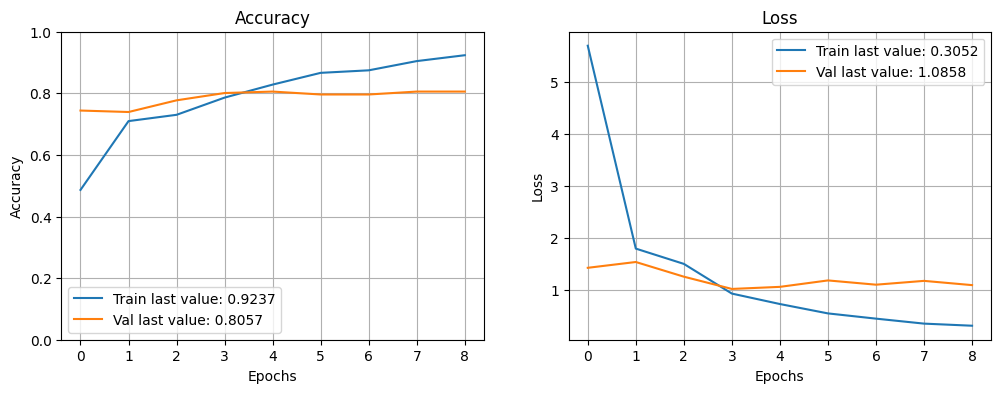

In [ ]:
# Afficher les courbes de train/val
plot_training_history(history3, train_val=True)

### Approche avec Data Augmentation

#### Modelisation

In [43]:
batch_size = 32

def dataset_fct(path, validation_split=0, data_type=None) :
    dataset = tf.keras.utils.image_dataset_from_directory(
                    path, labels='inferred', label_mode='categorical',
                    class_names=None, batch_size=batch_size, image_size=(224, 224), shuffle=True, seed=42,
                    validation_split=validation_split, subset=data_type
                    )
    return dataset

In [44]:
dataset_train = dataset_fct(train_path, validation_split=0, data_type=None)
dataset_val = dataset_fct(validation_path, validation_split=0, data_type=None)
dataset_test = dataset_fct(test_path, validation_split=0, data_type=None)

Found 734 files belonging to 7 classes.
Found 211 files belonging to 7 classes.
Found 105 files belonging to 7 classes.


In [ ]:
def resize_and_rescale(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = (image / 255.0)
    return image, label

In [42]:
class_count = len(df["cat_1"].unique())
class_count

7

In [ ]:
def create_model_fct2(data_augmentation) :
    # Récupération modèle pré-entraîné
    model_base = VGG16(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
    for layer in model_base.layers:
        layer.trainable = False

    # Définition du nouveau modèle
    model = Sequential([
                data_augmentation,
                Rescaling(1./127.5, offset=-1),
                model_base,
                GlobalAveragePooling2D(),
                Dense(256, activation='relu'),
                Dropout(0.5),
                Dense(class_count, activation='softmax')
                ])

    # compilation du modèle
    model.compile(loss="categorical_crossentropy", optimizer='adam', metrics=["accuracy"])

    print(model.summary())

    return model

In [ ]:
# Définir le modèle de data augmentation
data_augmentation = Sequential([
            Input(shape=(224, 224, 3)),
            RandomFlip("horizontal_and_vertical"),
            RandomRotation(0.4),
            RandomZoom(0.1),
            RandomTranslation(height_factor=0.1, width_factor=0.1),
            # Rescaling(1./127.5, offset=-1.0)
        ])

# Afficher le modèle de data augmentation
data_augmentation.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_7 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_7               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_7 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 224, 224, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Création du modèle
with tf.device('/gpu:0'):
    model4 = create_model_fct2(data_augmentation)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_10 (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

None


In [ ]:
# Création du callback
model_4_file = 'model4_best_weights.keras'
model4_save_path = get_path() + model_4_file

print(path)
print(model4_save_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/p6/data/Images/
/content/drive/MyDrive/Colab Notebooks/p6/data/model4_best_weights.keras


In [ ]:
checkpoint = ModelCheckpoint(model4_save_path, monitor='val_loss', verbose=1, save_best_only=True, mode='min')
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)
callbacks_list = [checkpoint, es]

#### Exécution

In [ ]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [ ]:
start_time = time.time()

with tf.device('/gpu:0'):
    history4 = model4.fit(dataset_train,
                    validation_data=dataset_val,
                    batch_size=batch_size, epochs=50, callbacks=callbacks_list, verbose=1)

end_time = time.time()

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.1902 - loss: 2.0240
Epoch 1: val_loss improved from inf to 1.51593, saving model to /content/drive/MyDrive/Colab Notebooks/p6/data/model4_best_weights.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 545ms/step - accuracy: 0.1928 - loss: 2.0183 - val_accuracy: 0.5118 - val_loss: 1.5159
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.3932 - loss: 1.5994
Epoch 2: val_loss improved from 1.51593 to 1.26493, saving model to /content/drive/MyDrive/Colab Notebooks/p6/data/model4_best_weights.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 425ms/step - accuracy: 0.3962 - loss: 1.5944 - val_accuracy: 0.6493 - val_loss: 1.2649
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.5592 - loss: 1.3153
Epoch 3: val_loss improved from 1.26493 to 1.10098, saving model to /content/drive/MyDrive/Colab Notebooks/p6/data/model4_best_weights.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 457ms/step - accuracy: 0.5604 - loss: 1.3131 - val_accur

In [ ]:
# Calcul du temps d'exécution
execution_time = end_time - start_time

print(f"Temps d'exécution : {execution_time:.2f} secondes")

Temps d'exécution : 335.31 secondes


#### Résultats

In [ ]:
# Score du dernier epoch

loss, accuracy = model4.evaluate(dataset_train, verbose=True)
print("Training Accuracy   : {:.4f}".format(accuracy))
print()
loss, accuracy = model4.evaluate(dataset_val, verbose=True)
print("Validation Accuracy :  {:.4f}".format(accuracy))

23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 277ms/step - accuracy: 0.8407 - loss: 0.4779
Training Accuracy   : 0.8515

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 313ms/step - accuracy: 0.7562 - loss: 0.8283
Validation Accuracy :  0.7867


In [ ]:
# Score de l'epoch optimal

model4.load_weights(model4_save_path)

loss, accuracy = model4.evaluate(dataset_val, verbose=False)
print("Validation Accuracy :  {:.4f}".format(accuracy))

loss, accuracy = model4.evaluate(dataset_test, verbose=False)
print("Test Accuracy       :  {:.4f}".format(accuracy))

Validation Accuracy :  0.7867
Test Accuracy       :  0.8095


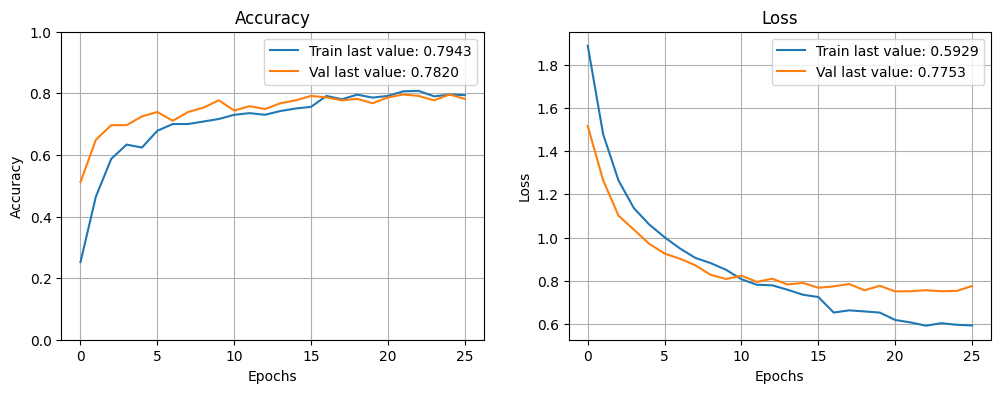

In [ ]:
plot_training_history(history4, train_val=True)

In [ ]:
# https://ebn.bmj.com/content/23/1/2

## Comparaison 3 modèles CNN : VGG16 / ResNet50V2 / NASNetMobile

In [ ]:
# liste modèles : https://keras.io/api/applications/

In [ ]:
#ResNet50V2

#NASNetMobile

### Préparation boucle

In [ ]:
def extract_features_and_visualize(model_name, preprocess_func, df, path):
    # Charger le modèle
    if model_name == "VGG16":
        base_model = VGG16(weights='imagenet')
    elif model_name == "ResNet50V2":
        base_model = ResNet50V2(weights='imagenet')
    elif model_name == "NASNetMobile":
        base_model = NASNetMobile(weights='imagenet')
    else:
        raise ValueError("Modèle non supporté")

    model = Model(inputs=base_model.inputs, outputs=base_model.layers[-2].output)

    print(model.summary())
    images_features = []
    i = 0
    for image_file in df["image"]:
        image_path = os.path.join(path, image_file)
        if i % 100 == 0:
            print(i)
        i += 1
        if os.path.exists(image_path):
            image = load_img(image_path, target_size=(224, 224))
            image = img_to_array(image)
            image = np.expand_dims(image, axis=0)
            image = preprocess_func(image)
            images_features.append(model.predict(image, verbose=0)[0])
        else:
            print(f"Image non trouvée: {image_path}")

    images_features = np.asarray(images_features)
    print(images_features.shape)

    pca = decomposition.PCA(n_components=0.99)
    feat_pca = pca.fit_transform(images_features)
    print(feat_pca.shape)

    temps1 = time.time()
    tsne = manifold.TSNE(n_components=2, perplexity=30, n_iter=2000, init='random', random_state=6)
    X_tsne = tsne.fit_transform(feat_pca)
    duration1 = time.time() - temps1
    print("Temps de T-SNE : ", "%15.2f" % duration1, "secondes")

    df_tsne = pd.DataFrame(X_tsne, columns=['tsne1', 'tsne2'])
    df_tsne["class"] = df["cat_1"]

    # Appliquer KMeans sur les données t-SNE
    kmeans = KMeans(n_clusters=len(df["cat_1"].unique()), random_state=42)
    clusters = kmeans.fit_predict(X_tsne)

    # Calculer le score ARI
    ari_score = metrics.adjusted_rand_score(df["cat_1"], clusters)
    print(f"Score ARI pour {model_name}: {ari_score:.4f}")

    return df_tsne, model_name, ari_score

### Exécution

In [ ]:
# Appeler la fonction pour chaque modèle et stocker les résultats
tsne_results = []
models = [
    ("VGG16", vgg16.preprocess_input),
    ("ResNet50V2", resnet_v2.preprocess_input),
    ("NASNetMobile", nasnet.preprocess_input)
]

for model_name, preprocess_func in models:
    tsne_results.append(extract_features_and_visualize(model_name, preprocess_func, df, path))

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

...

100
200
300
400
500
600


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


700
800
900
1000
(1050, 1056)
(1050, 539)


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Temps de T-SNE :            12.56 secondes
Score ARI pour NASNetMobile: 0.4888


### Résultats

In [ ]:
class_count = len(df_tsne["class"].unique())

def print_tsnes(tsne_results, class_count, order='horizontal'):
    # Déterminer la disposition des sous-graphiques
    if order == 'horizontal':
        nrows, ncols = 1, len(tsne_results)
        figsize = (18, 6)
    elif order == 'vertical':
        nrows, ncols = len(tsne_results), 1
        figsize = (8, 18)
    else:
        raise ValueError("L'argument 'order' doit être 'horizontal' ou 'vertical'.")

    # Créer la figure
    plt.figure(figsize=figsize)

    if nrows == 1 and ncols == 1:
        axes = [axes]  # Vérifier qu'axes est toujours une liste

    for i, (df_tsne, model_name, ari_score) in enumerate(tsne_results):
        plt.subplot(nrows, ncols, i + 1)
        sns.scatterplot(
            x="tsne1", y="tsne2",
            hue="class",
            palette=sns.color_palette('tab10', n_colors=class_count), s=50, alpha=0.6,
            data=df_tsne,
            legend="brief"
        )
        plt.title(f'TSNE avec {model_name}\nARI: {ari_score:.4f}', fontsize=20, pad=20, fontweight='bold')
        plt.xlabel('tsne1', fontsize=16, fontweight='bold')
        plt.ylabel('tsne2', fontsize=16, fontweight='bold')
        plt.legend(prop={'size': 10})

    plt.tight_layout()
    plt.show()

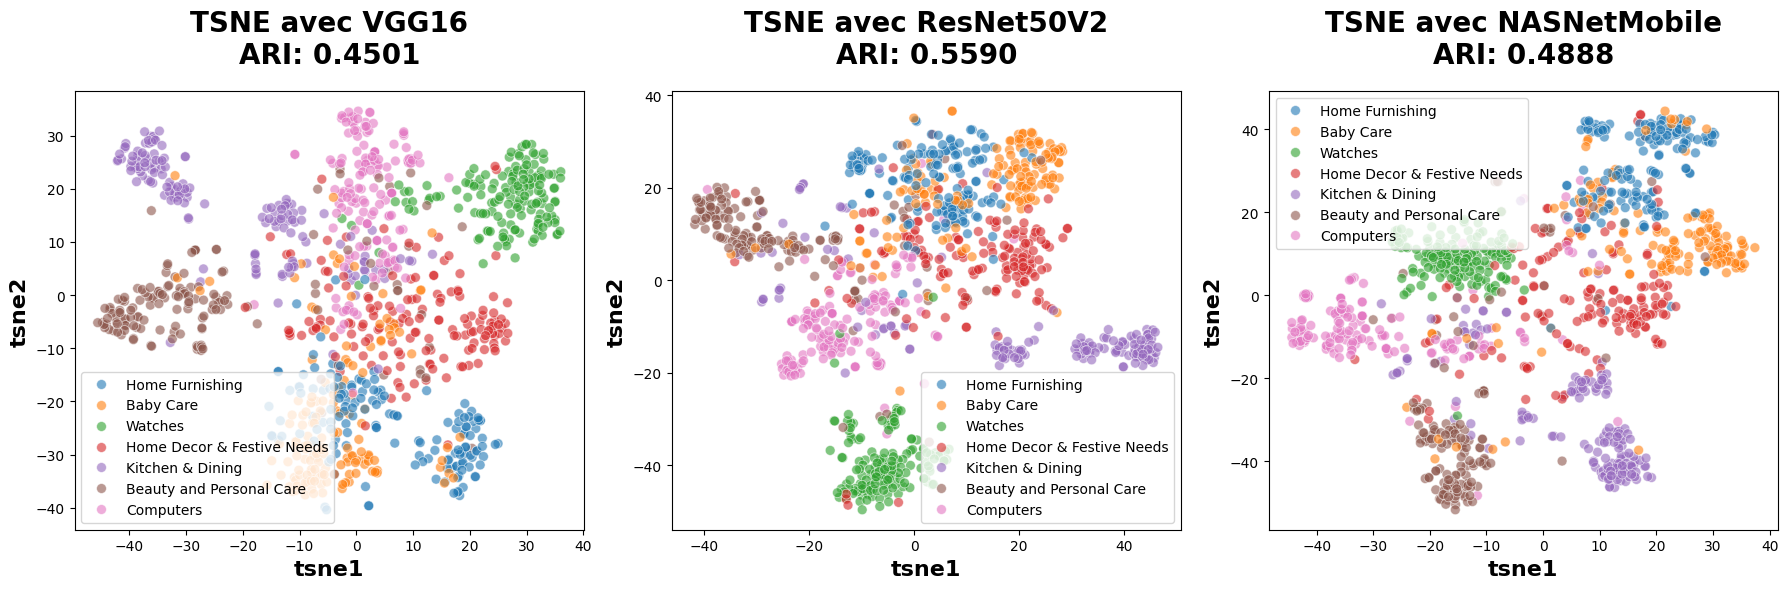

In [ ]:
print_tsnes(tsne_results, class_count)

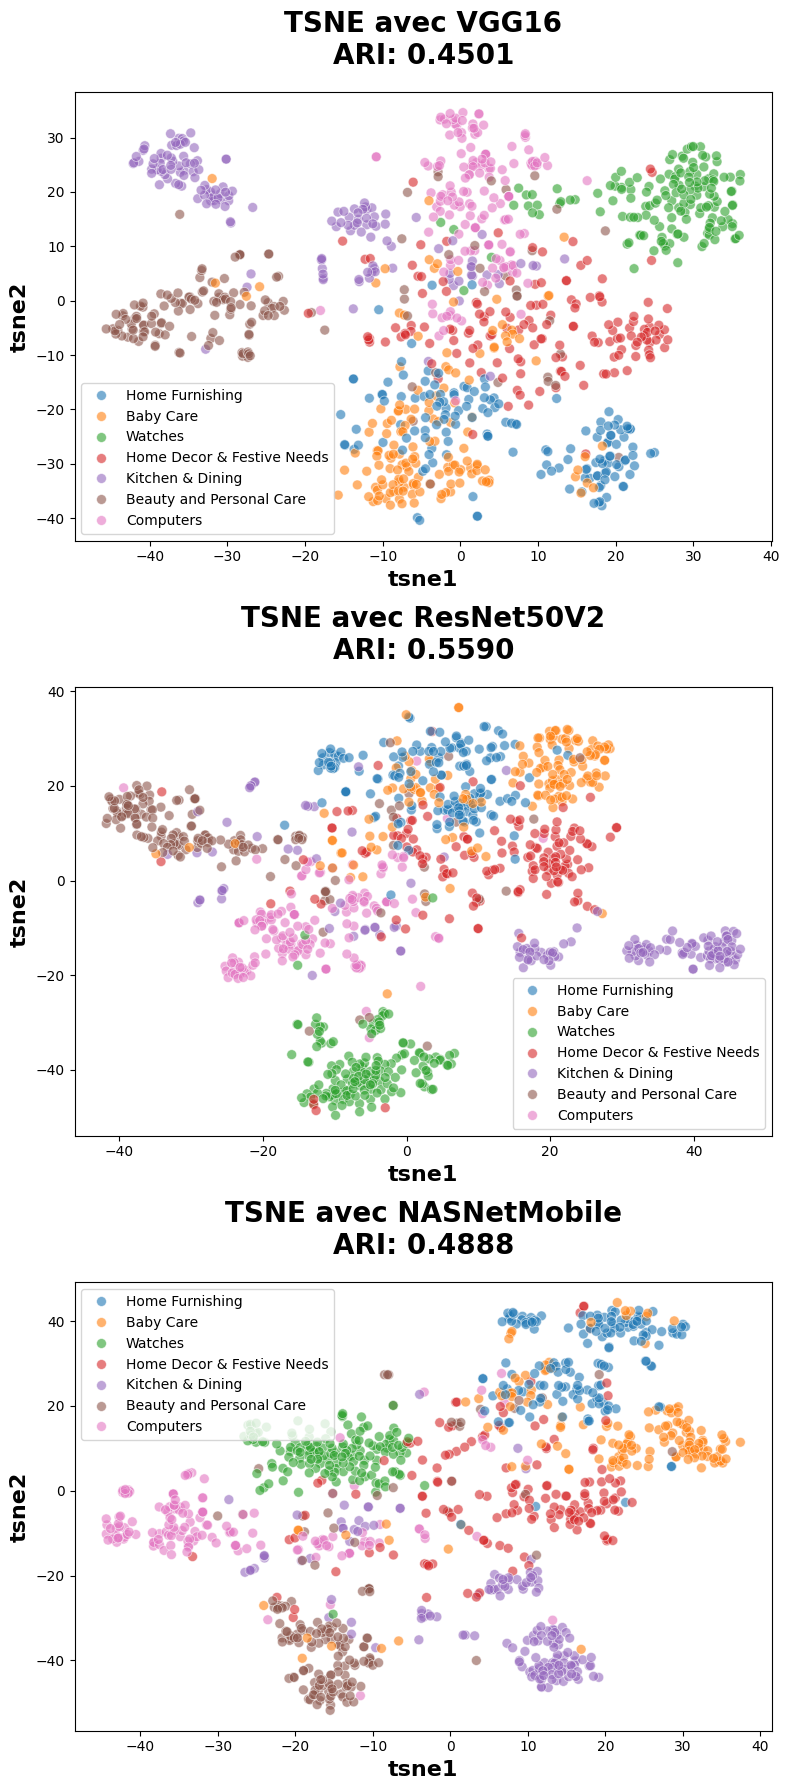

In [ ]:
print_tsnes(tsne_results, class_count, 'vertical')

=>